# Dataset Class

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class CTDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))  # alignment guaranteed

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]

        img = np.load(os.path.join(self.img_dir, f))   # (3, H, W)
        mask = np.load(os.path.join(self.mask_dir, f)) # (1, H, W)

        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return img, mask

## Train set

In [2]:
train_img_path = 'G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\train\\images'
train_mask_path = 'G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\train\\masks'

train_set = CTDataset(train_img_path, train_mask_path)

img, mask = train_set[0]

In [3]:
print("Image shape:", img.shape)
print("Mask shape :", mask.shape)

print("Image dtype:", img.dtype)
print("Mask dtype :", mask.dtype)

print("Mask unique values:", mask.unique())
print('Train len:', len(train_set))

Image shape: torch.Size([3, 256, 256])
Mask shape : torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype : torch.float32
Mask unique values: tensor([0.])
Train len: 2281


## Val set

In [4]:
val_img_path = 'G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\val\\images'
val_mask_path = 'G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\val\\masks'

val_set = CTDataset(val_img_path, val_mask_path)

img, mask = val_set[0]


In [5]:
print("Image shape:", img.shape)
print("Mask shape :", mask.shape)

print("Image dtype:", img.dtype)
print("Mask dtype :", mask.dtype)

print("Mask unique values:", mask.unique())

print('Validation len:', len(val_set))

Image shape: torch.Size([3, 256, 256])
Mask shape : torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype : torch.float32
Mask unique values: tensor([0.])
Validation len: 241


## Test set

In [6]:
test_img_path = 'G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\test\\images'
test_mask_path = 'G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\test\\masks'

test_set = CTDataset(test_img_path, test_mask_path)

img, mask = test_set[0]

In [7]:
print("Image shape:", img.shape)
print("Mask shape :", mask.shape)

print("Image dtype:", img.dtype)
print("Mask dtype :", mask.dtype)

print("Mask unique values:", mask.unique())

print('Test len:', len(test_set))

Image shape: torch.Size([3, 256, 256])
Mask shape : torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype : torch.float32
Mask unique values: tensor([0.])
Test len: 292


# Balanced Patch Sampling

In [8]:
import random
from torch.utils.data import Dataset

class BalancedPatchDataset(Dataset):
    def __init__(self, base_dataset, patch_size=128):
        self.base_dataset = base_dataset
        self.patch_size = patch_size

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, mask = self.base_dataset[idx]

        _, H, W = img.shape
        ps = self.patch_size

        want_positive = random.random() > 0.5

        for _ in range(10):  # try multiple times
            y = random.randint(0, H - ps)
            x = random.randint(0, W - ps)

            img_patch = img[:, y:y+ps, x:x+ps]
            mask_patch = mask[:, y:y+ps, x:x+ps]

            if want_positive:
                if mask_patch.sum() > 100:
                    return img_patch, mask_patch
            else:
                if mask_patch.sum() == 0:
                    return img_patch, mask_patch

        # fallback (important)
        return img_patch, mask_patch

In [9]:
train_patch_set = BalancedPatchDataset(train_set)

In [10]:
pos = 0
neg = 0

for i in range(100):
    _, mask = train_patch_set[i]
    if mask.sum() > 100:
        pos += 1
    else:
        neg += 1

print("Positive patches:", pos)
print("Negative patches:", neg)

Positive patches: 18
Negative patches: 82


In [11]:
import numpy as np

counts = []

for i in range(len(train_set)):
    _, mask = train_set[i]
    
    count = mask.sum().item()   # number of pixels == 1
    
    if count > 0:  # only positive slices
        counts.append(count)

counts = np.array(counts)

print("Number of positive slices:", len(counts))
print("Min:", counts.min())
print("Max:", counts.max())
print("Mean:", counts.mean())
print("Median:", np.median(counts))

Number of positive slices: 248
Min: 33.0
Max: 6599.0
Mean: 1063.9395161290322
Median: 436.0


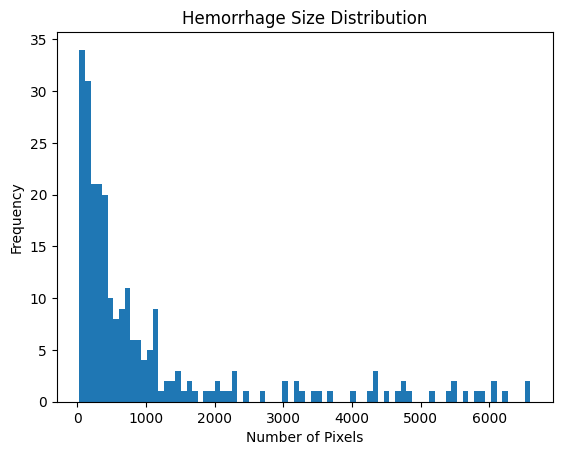

In [17]:
import matplotlib.pyplot as plt

plt.hist(counts, bins=80)
plt.title("Hemorrhage Size Distribution")
plt.xlabel("Number of Pixels")
plt.ylabel("Frequency")
plt.show()

In [27]:
import os
import numpy as np
from tqdm import tqdm

mask_dir = "G:\\My Drive\\brain_ct_project\\brain_ct_windowed_3ch\\train\\masks"

mask_pixels_per_image = []

files = sorted(os.listdir(mask_dir))

for f in tqdm(files):
    mask = np.load(os.path.join(mask_dir, f))
    mask_pixels_per_image.append(mask.sum())

print("Total samples:", len(mask_pixels_per_image))

100%|██████████| 2281/2281 [01:21<00:00, 27.99it/s]

Total samples: 2281


In [28]:
(mask > 0).astype(np.uint8)

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 256, 256), dtype=uint8)

In [32]:
values = np.array(mask_pixels_per_image)

percentiles = [10, 25, 50, 75, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

for p in percentiles:
    print(f"{p}th percentile:", np.percentile(values, p))

10th percentile: 0.0
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
89th percentile: 0.0
90th percentile: 89.0
91th percentile: 139.80000000000018
92th percentile: 200.39999999999918
93th percentile: 287.8000000000002
94th percentile: 373.1999999999971
95th percentile: 505.0
96th percentile: 709.5999999999995
97th percentile: 978.599999999999
98th percentile: 1492.8000000000025
99th percentile: 3554.5999999999685
